In [199]:
print("Hello! Welcome to the Corpus Linguistic Toolkit for Analysing (Brazilian) Portuguese.")
print("This program has compiled a large corpus with over 100.000 tokens, and can be analysed in many different ways.")

Hello! Welcome to the Corpus Linguistic Toolkit for Analysing (Brazilian) Portuguese.
This program has compiled a large corpus with over 100.000 tokens, and can be analysed in many different ways.


In [4]:
# for scraping
from bs4 import BeautifulSoup
from urllib.request import urlopen
import json

# for tokenization
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("gutenberg")
from nltk import tokenize
from nltk.tokenize import word_tokenize

#POS tagging
import spacy
from spacy.lang.pt.examples import sentences 

# word frequency
from nltk import FreqDist

# for visualization
import matplotlib.pyplot as plt
import numpy as np
from nltk import FreqDist
from nltk.text import Text
from nltk.corpus import stopwords
from sklearn.metrics import ConfusionMatrixDisplay
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /home/leschuvel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/leschuvel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/leschuvel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package gutenberg to
[nltk_data]     /home/leschuvel/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt to /home/leschuvel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/leschuvel/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/leschuvel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# 1 Corpus Collection and Organisation

In [5]:
urls = [
    #Biology
    "https://www.scielo.br/j/rbcan/a/XQ9Cp3vYPVY4ST4mthqMrGH/?lang=pt",
    "https://www.scielo.br/j/rlae/a/WShbNfN6dq5RXNp4kgMMBfk/?lang=pt",
    "https://www.scielo.br/j/asoc/a/873PJxPx9RG7Z5HWvKC6SKJ/?lang=pt",
    "https://www.scielo.br/j/rbso/a/VgrFfKHBkMvgRwpVhXxMCjv/?lang=pt",
    "https://www.scielo.br/j/rbcan/a/YYTxTn8ZxnWLc6j9dFSGWBP/?lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S1806-11172026000100433&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0102-46982026000100227&lang=pt",
    #Sociology
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S2178-27922026000102601&lang=pt2",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0103-20032026000100204&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0103-20032026000100205&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0103-20032026000100202&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0103-20032026000100207&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0103-20032026000100206&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0102-46982026000100206&lang=pt",
    #Literature
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S2316-40182018000100177&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S2316-40182023000100700&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S2596-304X2020000300136&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S0020-38742024000200600&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S1517-106X2021000300300&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S2316-40182018000100271&lang=pt",
    "http://www.scielo.br/scielo.php?script=sci_arttext&pid=S2237-101X2025000100200&lang=pt"
]

f =  open("corpus.txt", "w", encoding='utf-8')

# loop through list of urls and save text in corpus.txt
for url in urls:
    html = urlopen(url).read()
    soup = BeautifulSoup(html, "html.parser")

    paragraphs = soup.find_all("p")
    
    for p in paragraphs:
        text = p.get_text(" ", strip=True)
        f.write(text)
        f.write("\n")

f.close()

#save corpus into a variable

with open('corpus.txt', 'r', encoding="utf-8") as file:
    corpus = file.read()

In [6]:
#json file

import json

data = [
    {
    "title": "Identificação de MicroRNA Associados ao Diagnóstico e Prognóstico do Colangiocarcinoma",
    "source": "SciELO",
    "author": ["Darlene Silva de Souza", "Jamile Sofia Assis de Brito", "Lycia Lima Godoy", "Maressa de Pádua Neto Albino", "Maria Paula Alves Vilas Boas Cardoso", "Verônica Aparecida Silva Cintra", "Carlos Eduardo da Silva", "Sabrina Thalita dos Reis"], 
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
},
    {
    "title": "Infecções Sexualmente Transmissíveis não virais em gestantes na Atenção Primária: prevalência e fatores associados",
    "source": "SciELO",
    "author": ["Laura Almeida Vidal", "Maria Aparecida Araujo Figueiredo", "Ana Gabriela Alvares Travassos"], 
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Exposição ocupacional a substâncias químicas genotóxicas em laboratórios de diagnósticos clínicos e mecanismos celulares relacionados a danos no DNA: revisão sistemática de estudos observacionais",
    "source": "SciELO",
    "author": ["Ana Kamila Figueira Burlamaqui", "Fernanda Rabaioli da Silva", "Daiana Dalberto", "Juliana Da Silva"], 
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Integração da Classificação Molecular e Histopatológica: Um Caminho para Otimizar o Tratamento e o Prognóstico no Câncer de Endométrio",
    "source": "SciELO",
    "author": ["Eliane Gouvêa de Oliveira Barros", "Guilherme Tavares Cruz", "Maria Bethânia Souza Vilela", "Gabriela Silva Castro", "Jéssica Menezes do Nascimento", " Larissa Marques Gonçalves", "Olga Maria Silva Castro", "Anna Marcella Neves Dias", " Nathália Barbosa do Espírito Santo Mendes", "Bruno Aquino Marcelino"], 
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "A TEMÁTICA DA EDUCAÇÃO INCLUSIVA EM PROJETOS PEDAGÓGICOS DE CURSOS DE LICENCIATURA EM CIÊNCIAS BIOLÓGICAS",
    "source": "SciELO",
    "author": ["JULIANI FLÁVIA DE OLIVEIRA", "DENISE PEREIRA DE ALCANTARA FERRAZ"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Sobreviventes do tempo: as dores do encarceramento vivenciadas por internos idosos",
    "source": "SciELO",
    "author": ["Hosanah Pereira de Santana Filho", "Luiz Claudio Lourenço", "Uonis Raasch Pagel"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Comparação da estrutura produtiva agropecuária do Rio de Janeiro com o modelo paulista: análise locacional e estrutural shift-share",
    "source": "SciELO",
    "author": ["Frederico José Athayde Guimarães", "Janaina da Silva Braga Studenski", "Everlam Elias Montibeler"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Intensificação da pecuária e qualidade das pastagens no Cerrado goiano: uma análise comparativa entre sistemas de corte e leite",
    "source": "SciELO",
    "author": ["Franciele Fath", "Fausto Miziara", "Gabriel Caymmi Vilela Ferreira"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Modelos de negócio em propriedades rurais: uma revisão sistemática de literatura sob a ótica do ciclo do valor",
    "source": "SciELO",
    "author": ["Aécio Flávio de Paula Filho", "Dimária Silva e Meirelles"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "O acesso como objeto de análise em assistência técnica e extensão rural",
    "source": "SciELO",
    "author": ["Juliano Vitória Domingues", "Oscar José Rover"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Clubes de convergência e dinâmica de preços do trigo no Brasil, Estados Unidos e Argentina (2004–2024)",
    "source": "SciELO",
    "author": ["Laura Cunha Rebouças Lessa", "Francisco José Silva Tabosa", "Ahmad Saeed Khan", "Daniel Arruda Coronel", "Domingos Isaias Maia Amorim"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "BASIL BERNSTEIN E A SOCIOLOGIA DA EDUCAÇÃO",
    "source": "SciELO",
    "author": ["MANOEL AYUSSO MARTINS", "JEFFERSON MAINARDES"],
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "O avesso do direito à literatura: por uma definição de literatura indígena",
    "source": "SciELO",
    "author": ["Tarsilla Couto de Britto", "Sinval Martins de Sousa Filho", "Gláucia Vieira Cândido"],
    "year": "2018",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Carola Saavedra e a arte dos enigmas: sobre o poder e a impotência da literatura",
    "source": "SciELO",
    "author": ["Gabriela Dal Bosco Sitta", "Gabriel Victor Rocha Pinezi"],
    "year": "2023",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "PARA UMA LITERATURA COMPARADA À BRASILEIRA",
    "source": "SciELO",
    "author": "Regina Zilberman",
    "year": "2020",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Uma gênese da literatura contemporânea para crianças e jovens: O realismo na literatura juvenil, de Lenice Bueno",
    "source": "SciELO",
    "author": "Carlos Pires",
    "year": "2024",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "A biblioteca imaginária de Edson Rosa da Silva: antidestino e metamorfoses de uma reflexão da literatura",
    "source": "SciELO",
    "author": "Rodrigo Ielpo",
    "year": "2021",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Carta branca: embates entre a voz emergente e a escrita circunscrita",
    "source": "SciELO",
    "author": "Lívia Penedo Jacob",
    "year": "2018",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    },
    {
    "title": "Tragédia ou a redenção do mulato: contrastes da literatura brasileira e cubana, c. 1830 e c. 1870",
    "source": "SciELO",
    "author": "Ronald Raminelli",
    "year": "2026",
    "genre": "Scientific Article",
    "copyright/license":  "Creative Commons Attribution"
    }
]
    

file = open("output_corpus_data.json", "w")
json.dump(data, file, indent=4)
file.close()

file = open("output_corpus_data.json", "r")
data = json.load(file)

print(data)

[{'title': 'Identificação de MicroRNA Associados ao Diagnóstico e Prognóstico do Colangiocarcinoma', 'source': 'SciELO', 'author': ['Darlene Silva de Souza', 'Jamile Sofia Assis de Brito', 'Lycia Lima Godoy', 'Maressa de Pádua Neto Albino', 'Maria Paula Alves Vilas Boas Cardoso', 'Verônica Aparecida Silva Cintra', 'Carlos Eduardo da Silva', 'Sabrina Thalita dos Reis'], 'year': '2026', 'genre': 'Scientific Article', 'copyright/license': 'Creative Commons Attribution'}, {'title': 'Infecções Sexualmente Transmissíveis não virais em gestantes na Atenção Primária: prevalência e fatores associados', 'source': 'SciELO', 'author': ['Laura Almeida Vidal', 'Maria Aparecida Araujo Figueiredo', 'Ana Gabriela Alvares Travassos'], 'year': '2026', 'genre': 'Scientific Article', 'copyright/license': 'Creative Commons Attribution'}, {'title': 'Exposição ocupacional a substâncias químicas genotóxicas em laboratórios de diagnósticos clínicos e mecanismos celulares relacionados a danos no DNA: revisão sis

In [ ]:
# Pre-processing

In [7]:
#clean words
corpus_no_extra = corpus.replace("/s/s", "/s")

#sentence segmentation
sentences = tokenize.sent_tokenize(corpus)

In [8]:
#tokenize corpus

corpus_tokens = word_tokenize(corpus)

In [9]:
#lowercase tokens

lower_corpus_tokens = []

for token in corpus_tokens:
    lower_corpus_tokens.append(token.lower())

In [10]:
#remove punctuation

final_tokens = []

for token in lower_corpus_tokens:
    if token.isalpha():                          #remove non-letter characters
        final_tokens.append(token)
        
print("List of tokens: ", final_tokens)

List of tokens:  ['introdução', 'o', 'colangiocarcinoma', 'chol', 'é', 'uma', 'neoplasia', 'maligna', 'do', 'epitélio', 'biliar', 'sendo', 'a', 'segunda', 'principal', 'forma', 'de', 'câncer', 'hepático', 'sua', 'alta', 'agressividade', 'e', 'diagnóstico', 'tardio', 'dificultam', 'terapias', 'eficazes', 'a', 'falta', 'de', 'biomarcadores', 'prognósticos', 'confiáveis', 'também', 'impede', 'o', 'manejo', 'clínico', 'adequado', 'nesse', 'contexto', 'os', 'microrna', 'mirna', 'surgem', 'como', 'reguladores', 'da', 'expressão', 'gênica', 'com', 'potencial', 'diagnóstico', 'e', 'prognóstico', 'em', 'diversos', 'tumores', 'objetivo', 'identificar', 'os', 'principais', 'mirna', 'associados', 'ao', 'diagnóstico', 'e', 'prognóstico', 'do', 'chol', 'com', 'enfoque', 'especial', 'na', 'metástase', 'linfonodal', 'por', 'meio', 'da', 'análise', 'bioinformática', 'de', 'dados', 'obtidos', 'do', 'the', 'cancer', 'genome', 'atlas', 'tcga', 'método', 'estudo', 'transversal', 'descritivo', 'e', 'explora

In [11]:
#total number of tokens

print("Number of tokens: ", len(final_tokens))

Number of tokens:  119954


In [185]:
#extraction/filtering of texts
#source, genre and licence are the same for all the texts

In [12]:
#stop word removal

portuguese_stopwords = nltk.corpus.stopwords.words('portuguese')

content_words = []

for token in final_tokens:
    if token not in portuguese_stopwords:
        content_words.append(token)

print("The list of tokens (sans stopwords): ", content_words)

The list of tokens (sans stopwords):  ['introdução', 'colangiocarcinoma', 'chol', 'neoplasia', 'maligna', 'epitélio', 'biliar', 'sendo', 'segunda', 'principal', 'forma', 'câncer', 'hepático', 'alta', 'agressividade', 'diagnóstico', 'tardio', 'dificultam', 'terapias', 'eficazes', 'falta', 'biomarcadores', 'prognósticos', 'confiáveis', 'impede', 'manejo', 'clínico', 'adequado', 'nesse', 'contexto', 'microrna', 'mirna', 'surgem', 'reguladores', 'expressão', 'gênica', 'potencial', 'diagnóstico', 'prognóstico', 'diversos', 'tumores', 'objetivo', 'identificar', 'principais', 'mirna', 'associados', 'diagnóstico', 'prognóstico', 'chol', 'enfoque', 'especial', 'metástase', 'linfonodal', 'meio', 'análise', 'bioinformática', 'dados', 'obtidos', 'the', 'cancer', 'genome', 'atlas', 'tcga', 'método', 'estudo', 'transversal', 'descritivo', 'exploratório', 'baseado', 'ferramentas', 'bioinformática', 'analisadas', 'amostras', 'tumorais', 'normais', 'provenientes', 'tcga', 'triagem', 'filtragem', 'análi

In [ ]:
# 3 Linguistic Annotation

In [14]:
# POS tagging

#python -m spacy download pt_core_news_sm                  command for terminal
import spacy
from spacy.lang.pt.examples import sentences 

nlp = spacy.load("pt_core_news_sm")
doc = nlp(corpus)
for token in doc:
    print(token.text, token.pos_, token.dep_)

Introdução NOUN ROOT
: PUNCT punct
O DET det
colangiocarcinoma NOUN nsubj
( PUNCT punct
CHOL PROPN appos
) PUNCT punct
é AUX cop
uma DET det
neoplasia ADJ ROOT
maligna NOUN appos
do ADP case
epitélio NOUN nmod
biliar NOUN amod
, PUNCT punct
sendo AUX cop
a DET det
segunda ADJ amod
principal ADJ amod
forma NOUN conj
de ADP case
câncer NOUN nmod
hepático ADJ amod
. PUNCT punct
Sua DET det
alta ADJ amod
agressividade NOUN nsubj
e CCONJ cc
diagnóstico ADJ amod
tardio NOUN amod
dificultam VERB ROOT
terapias NOUN obj
eficazes ADJ amod
. PUNCT punct
A DET det
falta NOUN nsubj
de ADP case
biomarcadores NOUN nmod
prognósticos ADJ amod
confiáveis ADJ amod
também ADV advmod
impede VERB ROOT
o DET det
manejo NOUN obj
clínico ADJ amod
adequado ADJ amod
. PUNCT punct
Nesse ADP case
contexto NOUN obl
, PUNCT punct
os DET det
microRNA PROPN nsubj
( PUNCT punct
miRNA NOUN appos
) PUNCT punct
surgem VERB ROOT
como ADP case
reguladores NOUN obl
pós-transcricionais ADJ amod
da ADP case
expressão NOUN nmod

. PUNCT punct
Destas ADV advmod
, PUNCT punct
11 NUM nsubj:pass
foram AUX aux:pass
excluídas VERB ROOT
do ADP case
estudo NOUN obl
em ADP case
decorrência NOUN obl
do ADP case
uso NOUN nmod
de ADP case
antibiótico NOUN nmod
nos ADP case
últimos ADJ amod
três NUM nummod
meses NOUN nmod
( PUNCT punct
07 NUM appos
) PUNCT punct
e CCONJ cc
incompletude NOUN conj
do ADP case
questionário NOUN nmod
( PUNCT punct
04 NUM appos
) PUNCT punct
, PUNCT punct
resultando VERB advcl
em ADP case
uma DET det
amostra NOUN obl
de ADP case
302 NUM nummod
mulheres NOUN nmod
, PUNCT punct
mantendo VERB advcl
um DET det
n ADP case
superior NOUN obj
ao ADP case
mínimo NOUN obl
necessário ADJ amod
( PUNCT punct
278 NUM appos
) PUNCT punct
. PUNCT punct
Os DET det
cálculos NOUN nsubj:pass
amostrais ADJ amod
foram AUX aux:pass
realizados VERB ROOT
no ADP case
software NOUN obl
Open PROPN appos
Epi PROPN flat:name
versão NOUN obj
3 NUM nummod
, PUNCT punct
de ADP case
domínio NOUN nmod
público ADJ amod
. PUNCT pu

essa DET det
divisão NOUN obj
no ADP case
interior NOUN nmod
da ADP case
Antropologia NOUN nmod
e CCONJ cc
Biologia PROPN conj
. PUNCT punct
Pela ADP case
ótica NOUN ROOT
da ADP case
Antropologia NOUN nmod
, PUNCT punct
perspectivas NOUN appos
associadas VERB acl
ao ADP case
seu DET obl
“ NUM nummod
giro NOUN nsubj:pass
ontológico ADJ amod
” NUM punct
são AUX aux:pass
discutidas VERB ROOT
. PUNCT punct
Mas CCONJ cc
é AUX cop
no ADP case
conceito NOUN ROOT
de ADP case
“ NUM nmod
ambiente ADJ amod
” PUNCT punct
, PUNCT punct
de ADP case
Tim PROPN nmod
Ingold PROPN flat:name
, PUNCT punct
que SCONJ nsubj:pass
uma DET det
superação NOUN nsubj:pass
do ADP case
problema NOUN nmod
é AUX aux:pass
aqui ADV advmod
reconhecida VERB acl:relcl
. PUNCT punct
No ADP case
âmbito NOUN obl
da ADP case
Biologia PROPN nmod
, PUNCT punct
pensadores NOUN appos
como ADP case
Richard PROPN nmod
Lewontin PROPN flat:name
, PUNCT punct
Georges PROPN conj
Canguilhem PROPN flat:name
e CCONJ cc
Jakob PROPN conj
von

ou CCONJ cc
a DET det
textura NOUN conj
do ADP case
mundo NOUN nmod
da ADP case
vida NOUN nmod
, PUNCT punct
para SCONJ mark
citar VERB advcl
uma DET det
imagem NOUN obj
muito ADV advmod
usada VERB acl
por ADP case
Ingold PROPN obl:agent
. PUNCT punct
A DET det
linha NOUN nsubj
representa VERB ROOT
a DET det
dimensão NOUN obj
temporal ADJ amod
dos ADP case
fenômenos NOUN nmod
, PUNCT punct
o DET det
devir NOUN dep
de ADP case
tudo PRON obj
que PRON fixed
é AUX cop
vivo ADJ ccomp
e CCONJ cc
se PRON expl
constitui VERB conj
no ADP case
curso NOUN obl
de ADP case
sua DET det
existência NOUN nmod
, PUNCT punct
ao ADP case
longo NOUN obl
de ADP case
sua DET det
história NOUN nmod
. PUNCT punct
Os DET det
sistemas NOUN nsubj
de ADP case
desenvolvimento NOUN nmod
organismo-no-ambiente ADV advmod
se PRON expl
cruzam VERB ROOT
e CCONJ cc
se PRON expl
constituem VERB conj
reciprocamente ADV advmod
em ADP case
pontos NOUN obl
da ADP case
malha NOUN nmod
que PRON nsubj
representam VERB acl:relcl
a

base NOUN obj
para ADP case
a DET det
formulação NOUN obl
de ADP case
ações NOUN nmod
regulatórias ADJ amod
e CCONJ cc
para ADP case
o DET det
fortalecimento NOUN conj
da ADP case
Vigilância PROPN nmod
em ADP case
Saúde PROPN nmod
do ADP case
Trabalhador PROPN nmod
. PUNCT punct

 SPACE dep
A DET det
análise NOUN nsubj
dos ADP case
estudos NOUN nmod
incluídos VERB acl
nesta ADP case
revisão NOUN obl
indicou VERB ROOT
24 NUM nummod
substâncias NOUN obj
potencialmente ADV advmod
genotóxicas ADJ amod
utilizadas VERB acl
nos ADP case
laboratórios NOUN obl
diagnósticos ADJ amod
. PUNCT punct
O DET det
formaldeído NOUN nsubj
foi AUX cop
a DET det
substância NOUN ROOT
mais ADV advmod
identificada VERB acl
nos ADP case
ambientes NOUN obl
de ADP case
trabalho NOUN nmod
, PUNCT punct
além ADV advmod
do ADP case
n-hexano NOUN obl
e CCONJ cc
do ADP case
metanol NOUN conj
. PUNCT punct
Benzeno PROPN nsubj:pass
, PUNCT punct
xileno ADJ conj
, PUNCT punct
solventes NOUN conj
orgânicos ADJ amod
em ADP

...

. PUNCT punct
Leitor NOUN advmod
atento ADJ amod
de ADP case
Walter PROPN nmod
Benjamin PROPN flat:name
, PUNCT punct
Edson PROPN nsubj
parece VERB ROOT
, PUNCT punct
assim ADV advmod
, PUNCT punct
aproximar-se VERB xcomp
das ADP case
reflexões NOUN obj
que PRON obj
o DET det
filósofo NOUN nsubj
alemão ADJ amod
faz VERB acl:relcl
sobre ADP case
o DET det
conceito NOUN obj
de ADP case
crítica NOUN nmod
de ADP case
arte NOUN nmod
para ADP case
os DET det
românticos NOUN nmod
alemães ADJ amod
, PUNCT punct
crítica VERB conj
essa PRON obj
que PRON nsubj
falaria VERB acl:relcl
de ADP case
“ NUM nmod
um DET det
desdobramento NOUN obj
e CCONJ cc
de ADP case
uma DET det
intensificação NOUN conj
continuamente ADV advmod
mais ADV advmod
abrangentes ADV amod
das ADP case
formas NOUN obl
poéticas ADJ amod
” PUNCT punct
, PUNCT punct
entendendo-a VERB conj
, PUNCT punct
então ADV advmod
, PUNCT punct
como ADP case
“ PROPN dep
um DET det
processo NOUN obj
de ADP case
realização NOUN nmod
infinito AD

2009 NUM conj
, PUNCT punct
p. NOUN conj
13 NUM nummod
) PUNCT punct
. PUNCT punct


 SPACE dep
Pelo ADP case
relato NOUN obl
de ADP case
Munduruku PROPN nmod
, PUNCT punct
depreende-se VERB ROOT
que SCONJ mark
, PUNCT punct
em ADP case
sua DET det
aldeia NOUN obl
, PUNCT punct
o DET det
papel NOUN nsubj
de ADP case
contadores NOUN nmod
de ADP case
histórias NOUN nmod
era AUX aux:pass
desempenhado VERB ccomp
principalmente ADV advmod
pelos ADP case
idosos NOUN obl
, PUNCT punct
que PRON nsubj
, PUNCT punct
devido ADV advmod
a ADP case
essa DET det
função NOUN obl
, PUNCT punct
ganhavam VERB acl:relcl
status NOUN obj
e CCONJ cc
notoriedade NOUN conj
diante ADV case
dos DET det
membros NOUN obl
mais ADV advmod
jovens ADJ amod
. PUNCT punct
É AUX cop
certo ADJ ROOT
que SCONJ mark
outros DET det
grupos NOUN nsubj
possuem VERB csubj
suas DET det
especificidades NOUN obj
em ADP case
relação NOUN fixed
aos DET det
contadores NOUN obl
de ADP case
história NOUN nmod
e CCONJ cc
seria AUX cop
pre

. PUNCT punct

 SPACE dep
Palavras-chave NOUN ROOT
: PUNCT punct
literatura NOUN appos
; PUNCT punct
escravidão NOUN appos
; PUNCT punct
mulatos NOUN conj
; PUNCT punct
Cuba PROPN appos
; PUNCT punct
Brasil PROPN appos

 SPACE dep
This NOUN ROOT
paper VERB amod
compares PROPN nmod
Brazilian PROPN appos
and PROPN flat:name
Cuban PROPN flat:name
anti-slavery PROPN flat:name
literature VERB flat:name
between PROPN flat:name
1830 NUM flat:name
and PROPN flat:name
1870 NUM flat:name
, PUNCT punct
highlighting PROPN appos
the PROPN flat:name
use PROPN flat:name
of PROPN obj
almost-white PROPN flat:name
mulatto PROPN appos
protagonists PROPN amod
to PROPN flat:name
denounce VERB flat:name
slavery PROPN flat:name
and PROPN flat:name
the PROPN flat:name
racial ADJ amod
hierarchies PROPN flat:name
of PROPN ROOT
slaveholding PROPN flat:name
societies PROPN flat:name
. PUNCT punct
The DET det
analysis PROPN nsubj
begins NOUN amod
with PROPN appos
the PROPN flat:name
theoretical PROPN amod
debate N

. PUNCT punct
Para ADP case
Alencar PROPN obl
, PUNCT punct
o DET det
povo NOUN nsubj
brasileiro ADJ amod
não ADV advmod
se PRON expl
forjou VERB ROOT
com ADP case
a DET det
resistência NOUN obj
heroica ADJ amod
, PUNCT punct
mas CCONJ cc
com ADP case
a DET det
rendição NOUN conj
romântica ADJ amod
. PUNCT punct
Sua DET det
fundação NOUN nsubj
aconteceu VERB ROOT
quando ADV advmod
os DET det
brancos NOUN nsubj
e CCONJ cc
os DET det
índios NOUN nsubj
caíram VERB advcl
nos ADP case
braços NOUN obl
um NUM obl
do ADP case
outro PRON nmod
para SCONJ mark
criar VERB advcl
uma DET det
prole NOUN obj
mestiça ADJ amod
( PUNCT punct
SOMMER PROPN appos
, PUNCT punct
1991 NUM conj
, PUNCT punct
p. NOUN conj
150 NUM nummod
) PUNCT punct
. PUNCT punct
No ADP case
teatro NOUN nmod
brasileiro ADJ amod
oitocentista ADJ amod
, PUNCT punct
a DET det
formação NOUN nsubj
da ADP case
família NOUN nmod
mestiça ADJ amod
era AUX cop
tema NOUN ROOT
recorrente ADV advmod
. PUNCT punct
Essa DET det
dramaturgia NO

as DET det
brancas NOUN obj
recebido VERB acl
os DET det
mesmos ADJ amod
elogios NOUN obj
. PUNCT punct
A DET det
quase ADV advmod
caucasiana ADJ amod
Florinda PROPN nsubj
, PUNCT punct
mulata NOUN conj
escravizada ADJ amod
, PUNCT punct
encantava VERB ROOT
os DET det
homens NOUN obj
com ADP case
sua DET det
beleza NOUN obl
e CCONJ cc
honestidade NOUN conj
. PUNCT punct
Nos ADP case
romances NOUN obl
, PUNCT punct
a DET det
mestiçagem NOUN nsubj
entre ADP case
brancos NOUN nmod
e CCONJ cc
negros NOUN conj
/ ADP case
mulatos NOUN conj
podia VERB ROOT
originar VERB xcomp
brancos ADJ obj
, PUNCT punct
e CCONJ cc
a DET det
origem NOUN nsubj
africana ADJ amod
nem ADV advmod
sempre ADV advmod
era AUX cop
o DET det
motivo NOUN xcomp
da ADP case
exclusão NOUN nmod
social ADJ amod
. PUNCT punct
Por ADP case
isso PRON obl
, PUNCT punct
as DET det
classificações NOUN nsubj
eram AUX cop
instáveis ADJ ROOT
, PUNCT punct
e CCONJ cc
os DET det
matizes NOUN nsubj
de ADP case
cores NOUN nmod
estavam AU

In [ ]:
# 4 Data Analysis

The 20 most common words in the corpus before stop word removal are:  [('de', 4778), ('a', 4092), ('e', 3386), ('o', 2874), ('que', 2072), ('do', 1957), ('da', 1681), ('em', 1595), ('os', 1066), ('no', 972), ('com', 857), ('por', 848), ('um', 847), ('para', 842), ('é', 827), ('uma', 823), ('como', 754), ('na', 742), ('as', 720), ('dos', 639)]
Bar chart of the 20 most frequent words in the corpus


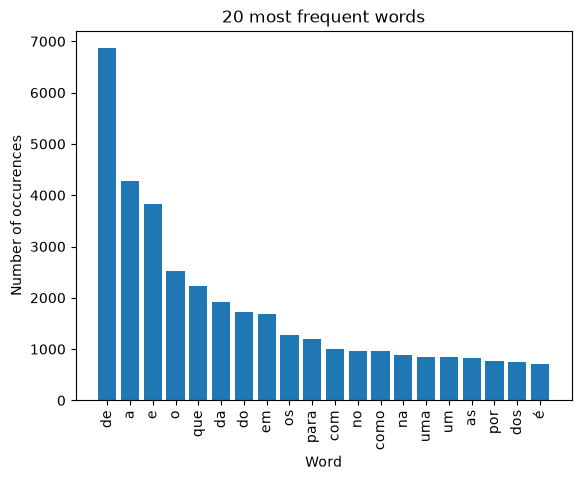

In [192]:
# word frequency analysis 

# count frequency
freq_words = FreqDist(final_tokens)
most_common_words = freq_words.most_common(20)

#turn words into list
common_words = []

for i in most_common_words:
    common_words.append(i[0])
    
#turn counts into list
common_counts = []

for i in most_common_words:
    common_counts.append(i[1])

print("The 20 most common words in the corpus before stop word removal are: ", most_common_before)
print("Bar chart of the 20 most frequent words in the corpus")
plt.bar(common_words, common_counts)
plt.xlabel("Word")
plt.ylabel("Number of occurences")
plt.title("20 most frequent words")
plt.xticks(rotation=90)                         #rotation of the words
plt.show() 

In [193]:
#the 20 most frequent characters

chars_freq = {}

for c in corpus:
    if c in chars_freq:
        chars_freq[c] += 1
    else:
        chars_freq[c] = 1
        
print("Character frequency in corpus: ", chars_freq)

Character frequency in corpus:  {'I': 892, 'n': 35763, 't': 35243, 'r': 43397, 'o': 65082, 'd': 35037, 'u': 21885, 'ç': 5933, 'ã': 5996, ':': 595, ' ': 129388, 'O': 1179, 'c': 27609, 'l': 20602, 'a': 77259, 'g': 7851, 'i': 49029, 'm': 25636, '(': 2349, 'C': 1318, 'H': 356, 'L': 735, ')': 2391, 'é': 2292, 'e': 77147, 'p': 17244, 's': 55351, 'b': 5584, ',': 10843, 'f': 6719, 'â': 678, 'h': 3508, 'á': 2524, '.': 5303, 'S': 1289, 'v': 8305, 'ó': 1645, 'z': 2000, 'A': 2140, 'j': 1107, 'í': 2550, 'q': 4129, 'N': 1250, 'x': 2178, 'R': 1105, '-': 1605, 'ê': 1244, '\n': 1756, 'T': 783, 'G': 532, 'M': 747, 'E': 1722, 'F': 872, '4': 668, '5': 708, '3': 887, '6': 592, '9': 1055, 'P': 1172, 'à': 760, 'U': 323, '2': 2566, '7': 631, '1': 2441, '8': 646, '0': 2387, '/': 242, ';': 723, 'B': 1009, '&': 103, 'y': 601, 'k': 285, 'w': 290, 'K': 182, 'ú': 452, 'õ': 1319, 'Á': 27, '%': 322, 'J': 237, 'V': 321, '–': 98, 'D': 787, '<': 19, '|': 4, '>': 13, 'É': 64, 'º': 45, '"': 20, 'Z': 41, 'β': 12, 'X': 71, 

In [ ]:
# 5 Corpus Analysis

In [ ]:
# Token-Type Ratio (TTR)

unique_count = {}

for i in final_tokens:
    if i in unique_count:
        unique_count[i] += 1
    else:
        unique_count[i] = 1
        
x = len(unique_count)
y = len(final_tokens)
    
print("The Token-Type Ratio for the corpus is: ", x / y * 100)

In [ ]:
# Concordance generation/KWIC (Key Word in Context) analysis

kc = input("Please enter a keyword for context search: \n")
sample_nltk_text = Text(final_tokens)
sample_nltk_text.concordance(keyword_context)

In [ ]:
# 6 Corpus search

In [ ]:
# Keyword search

keyword = input("Please enter a keyword: \n")
if keyword in corpus:
    print("The word [", keyword, "] was found in the corpus.")

In [ ]:
# Pattern search

pat = input("Please enter a pattern for search: \n")
pat_result = re.search(pat, corpus)
if pat_result == True:
    print("Pattern found: {pat_result.group()}")
else:
    print("No pattern match found.")

In [ ]:
# Annotation-based search

tokens_pos = []
POS_tag = input("Please enter a POS for search: \n")       
matching_tokens = [token.text for token in doc if token.pos_ == POS_tag]
print(matching_tokens)

Bar chart of the most common POS in the corpus


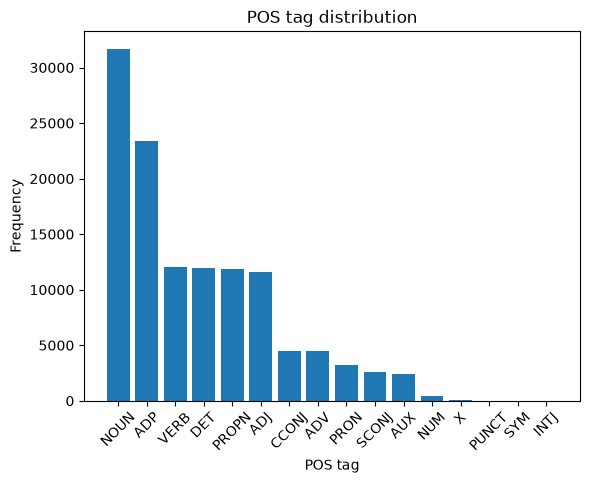

In [140]:
#POS tag frequency graph

pos_tags = []
for token in doc:
    if token.is_alpha:
        pos_tags.append(token.pos_)
pos_fdist = FreqDist(pos_tags)
print("The most common POS are: ", pos_fdist.most_common())

most_common = pos_fdist.most_common()

tags = []
counts = []

for tag, count in most_common:
    tags.append(tag)
    counts.append(count)

plt.bar(tags, counts)
plt.xlabel("POS tag")
plt.ylabel("Frequency")
plt.title("POS tag distribution")
plt.xticks(rotation=45) 
plt.show()

In [ ]:
# 7 N-gram analysis

In [32]:
# unigram analysis

from collections import Counter

unigrams = [i for i in final_tokens if i.isalnum() and i not in portuguese_stopwords]
unigram_counts = Counter(unigrams)
print("10 most common unigrams: ", unigram_counts.most_common(10))

10 most common unigrams:  [('literatura', 352), ('sobre', 313), ('et', 280), ('i', 257), ('the', 252), ('brasil', 202), ('estudo', 196), ('análise', 195), ('educação', 191), ('of', 183)]


In [31]:
# bigram analysis

from nltk.util import bigrams

bigrams = list(bigrams(final_tokens))
bigram_counts = Counter(bigrams)
print("10 most common bigrams: ", bigram_counts.most_common(10))

10 most common bigrams:  [(('e', 'a'), 202), (('para', 'a'), 178), (('que', 'a'), 176), (('de', 'uma'), 156), (('que', 'o'), 155), (('o', 'que'), 153), (('a', 'partir'), 152), (('e', 'o'), 136), (('com', 'a'), 130), (('et', 'al'), 122)]


In [30]:
# trigram analysis

from nltk.util import trigrams

trigrams = list(trigrams(final_tokens))
trigram_counts = Counter(trigrams)
# print("Most common trigrams:")
# for trigram, count in frequency.most_common():
#     print(f"{trigram}: {count} time(s)")
print("10 most common trigrams: ", bigram_counts.most_common(10))

10 most common trigrams:  [(('de', 'dinâmica', 'molecular'), 71), (('assistência', 'técnica', 'e'), 66), (('rio', 'de', 'janeiro'), 62), (('técnica', 'e', 'extensão'), 59), (('e', 'extensão', 'rural'), 59), (('a', 'partir', 'de'), 53), (('a', 'partir', 'da'), 49), (('campo', 'de', 'força'), 43), (('dinâmica', 'molecular', 'clássica'), 40), (('sociologia', 'da', 'educação'), 40)]
